In [71]:
import pandas as pd

In [72]:
df = pd.read_csv('../vacancies.csv')

In [73]:
# функция для вычисления описательных статистик для определенного уровня опыта

In [74]:
# Стратегия с исключением строк с NaN

In [75]:
def getStatisticsWithOutNaN(df: pd.DataFrame, experience: str) -> pd.DataFrame:
    df_experience = df[df['experience'] == experience]
    df_experience = df_experience.dropna()

    mean_salary = (df_experience['salary_from'] + df_experience['salary_to']) / 2
    
    return pd.DataFrame({
        'Медиана' : [mean_salary.median()],
        'Среднее' : [mean_salary.mean()],
        'Стандартное отклонение' : [mean_salary.std()],
        '25-й перцентиль' : [mean_salary.quantile(0.25)],
        '75-й перцентиль' : [mean_salary.quantile(0.75)]
    })

In [76]:
getStatisticsWithOutNaN(df, 'Нет опыта')

,Медиана,Среднее,Стандартное отклонение,25-й перцентиль,75-й перцентиль
0,80000.0,259869.276958,1.221016e+06,62500.0,95000.0


In [77]:
getStatisticsWithOutNaN(df, 'От 1 года до 3 лет')

,Медиана,Среднее,Стандартное отклонение,25-й перцентиль,75-й перцентиль
0,150000.0,595985.095603,3.121773e+06,110000.0,220000.0


In [78]:
getStatisticsWithOutNaN(df, 'От 3 до 6 лет')

,Медиана,Среднее,Стандартное отклонение,25-й перцентиль,75-й перцентиль
0,170000.0,564468.436025,2.759139e+06,125000.0,225000.0


In [79]:
getStatisticsWithOutNaN(df, 'Более 6 лет')

,Медиана,Среднее,Стандартное отклонение,25-й перцентиль,75-й перцентиль
0,315000.0,1.068547e+06,5.193828e+06,235000.0,402500.0


In [80]:
# функция для вычисления описательных статистик для определенного уровня опыта

In [81]:
''' Если обе границы зарплаты NaN, то заменяем NaN`ы на медианы соответствующих столбцов
    Если только одна из границ - дублируем существующую (тогда получится усреднённое будет то же значение)
'''

' Если обе границы зарплаты NaN, то заменяем NaN`ы на медианы соответствующих столбцов\n    Если только одна из границ - дублируем существующую (тогда получится усреднённое будет то же значение)\n'

In [82]:
# Замена NaN`ов на медианы на столбцов или на существующие противоположные границы

In [83]:
def replace_nan_on_median_or_opposite_border(df: pd.DataFrame) -> pd.DataFrame:
    median_salary_from = df['salary_from'].median()
    median_salary_to = df['salary_to'].median()

    # Заполняем salary_from из salary_to (где salary_to не NaN)
    mask = df['salary_from'].isna() & df['salary_to'].notna()
    df.loc[mask, 'salary_from'] = df.loc[mask, 'salary_to']

    # Заполняем salary_to из salary_from (где salary_from не NaN)
    mask = df['salary_to'].isna() & df['salary_from'].notna()
    df.loc[mask, 'salary_to'] = df.loc[mask, 'salary_from']

    # Заполняем оставшиеся NaN медианами
    df['salary_from'] = df['salary_from'].fillna(median_salary_from)
    df['salary_to'] = df['salary_to'].fillna(median_salary_to)

    return df
    

In [84]:
def getStatisticsButNaNReplacedMedianAndOpposite_border(df: pd.DataFrame, experience: str) -> pd.DataFrame:
    df_experience = df[df['experience'] == experience]
    df_experience = replace_nan_on_median_or_opposite_border(df_experience)

    mean_salary = (df_experience['salary_from'] + df_experience['salary_to']) / 2
    
    return pd.DataFrame({
        'Медиана' : [mean_salary.median()],
        'Среднее' : [mean_salary.mean()],
        'Стандартное отклонение' : [mean_salary.std()],
        '25-й перцентиль' : [mean_salary.quantile(0.25)],
        '75-й перцентиль' : [mean_salary.quantile(0.75)]
    })

In [85]:
getStatisticsButNaNReplacedMedianAndOpposite_border(df, 'Нет опыта')

,Медиана,Среднее,Стандартное отклонение,25-й перцентиль,75-й перцентиль
0,80000.0,223924.729387,1.095342e+06,62500.0,95000.0


In [86]:
getStatisticsButNaNReplacedMedianAndOpposite_border(df, 'От 1 года до 3 лет')

,Медиана,Среднее,Стандартное отклонение,25-й перцентиль,75-й перцентиль
0,147500.0,475007.758146,2.658521e+06,117500.0,195000.0


In [87]:
getStatisticsButNaNReplacedMedianAndOpposite_border(df, 'От 3 до 6 лет')

,Медиана,Среднее,Стандартное отклонение,25-й перцентиль,75-й перцентиль
0,170000.0,388476.935667,2.059109e+06,150000.0,192500.0


In [88]:
getStatisticsButNaNReplacedMedianAndOpposite_border(df, 'Более 6 лет')

,Медиана,Среднее,Стандартное отклонение,25-й перцентиль,75-й перцентиль
0,315000.0,608256.77104,3.253206e+06,315000.0,315000.0


In [89]:
# A2. Во всех группах среднее выше медианы. Это указывает на правостороннюю скошенность распределений: относительно небольшое число высоких 
# зарплат «тянет» среднее вверх, тогда как медиана устойчива к таким выбросам.

In [90]:
# A3. Гистограммы распределения зарплат для каждого уровня опыта

In [91]:
import matplotlib.pyplot as plt

In [92]:
def getMeanSalaryForExperienceGroup(df: pd.DataFrame, experience):
    df_experience = df[df['experience'] == experience]
    df_experience = df_experience.dropna()
    
    list_mean_salaries = (df_experience['salary_from'] + df_experience['salary_to']) / 2
    return list_mean_salaries

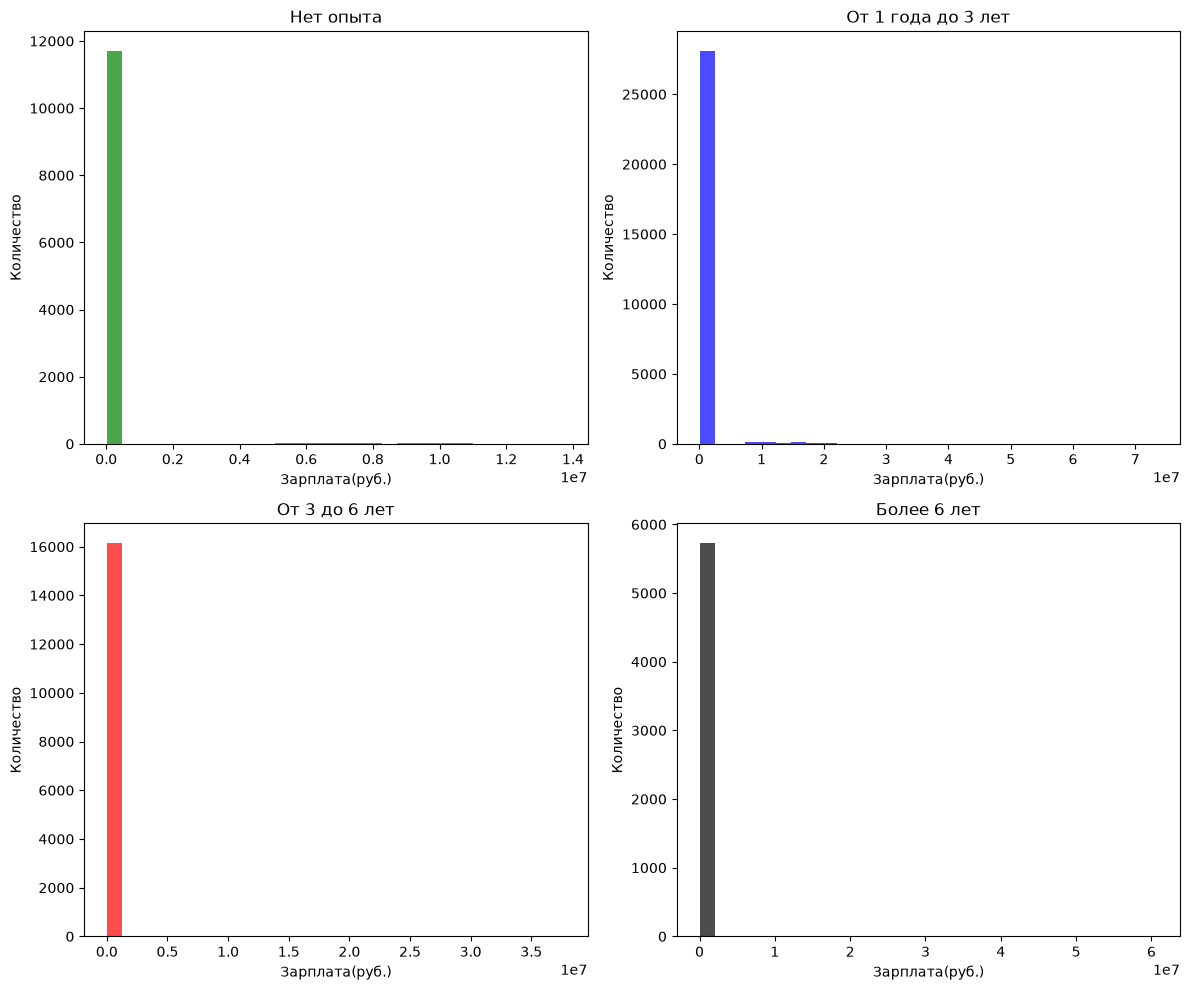

In [103]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Гистограмма для 'Нет опыта'
axes[0, 0].hist(getMeanSalaryForExperienceGroup(df, 'Нет опыта'), bins=30, color='green', alpha=0.7)
axes[0, 0].set_title('Нет опыта')
axes[0, 0].set_xlabel('Зарплата(руб.)')
axes[0, 0].set_ylabel('Количество')

# Гистограмма для 'От 1 года до 3 лет'
axes[0, 1].hist(getMeanSalaryForExperienceGroup(df, 'От 1 года до 3 лет'), bins=30, color='blue', alpha=0.7)
axes[0, 1].set_title('От 1 года до 3 лет')
axes[0, 1].set_xlabel('Зарплата(руб.)')
axes[0, 1].set_ylabel('Количество')

# Гистограмма для 'От 3 до 6 лет'
axes[1, 0].hist(getMeanSalaryForExperienceGroup(df, 'От 3 до 6 лет'), bins=30, color='red', alpha=0.7)
axes[1, 0].set_title('От 3 до 6 лет')
axes[1, 0].set_xlabel('Зарплата(руб.)')
axes[1, 0].set_ylabel('Количество')

# Гистограмма для 'Более 6 лет'
axes[1, 1].hist(getMeanSalaryForExperienceGroup(df, 'Более 6 лет'), bins=30, color='black', alpha=0.7)
axes[1, 1].set_title('Более 6 лет')
axes[1, 1].set_xlabel('Зарплата(руб.)')
axes[1, 1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

In [94]:
# Как видно на графиках выше, наблюдается правосторонняя скошенность распределений для всех выборок по опыту

In [ ]:
# Для большей наглядности можно построить ящики с усами, чтобы показат, что распределение в выборках не является норальным

{'whiskers': [<matplotlib.lines.Line2D at 0x7863afbf1be0>,
 'caps': [<matplotlib.lines.Line2D at 0x7863afbf1e80>,
 'boxes': [<matplotlib.lines.Line2D at 0x7863afbf1a90>],
 'medians': [<matplotlib.lines.Line2D at 0x7863afbf2120>],
 'fliers': [<matplotlib.lines.Line2D at 0x7863afbf2270>],
 'means': []}

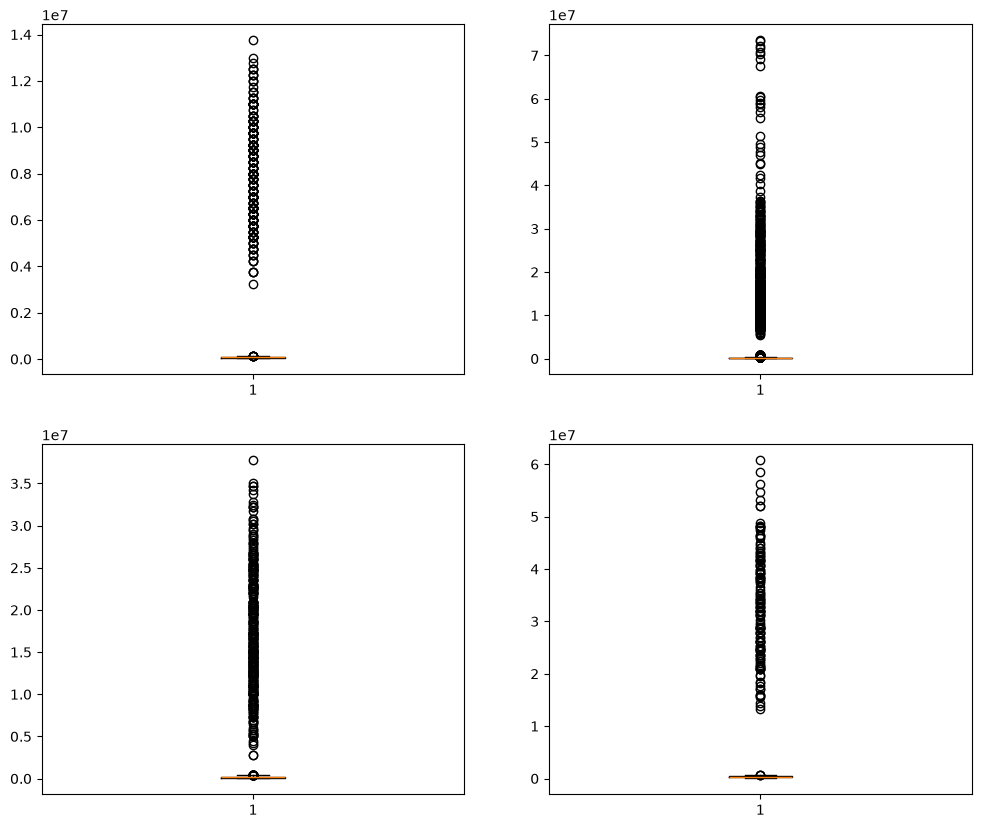

In [110]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0, 0].boxplot(getMeanSalaryForExperienceGroup(df, 'Нет опыта'))
axes[0, 1].boxplot(getMeanSalaryForExperienceGroup(df, 'От 1 года до 3 лет'))
axes[1, 0].boxplot(getMeanSalaryForExperienceGroup(df, 'От 3 до 6 лет'))
axes[1, 1].boxplot(getMeanSalaryForExperienceGroup(df, 'Более 6 лет'))

